# EDA in pandas and duckdb for Stockholm cultural events (Metrics and KPI) 

In [1]:
# Import (Pandas + DuckDB + Matplotlib)

import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [4]:
# Load data and quick checks/exploration of dataset

df = pd.read_csv("data/output/clean_events.csv")

df.head()


,event_id,name,url,image_url,date,time,status,venue_id,category_id,segment,...,venue_name,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour
0,Z698xZq2Z1kAoaYe7,STOCKHOLM INTERNATIONAL TAP DANCE FESTIVAL,https://www.ticketmaster.se/event/stockholm-in...,https://s1.ticketm.net/dam/a/d2f/8582cce8-a129...,2026-04-05,20:00,onsale,Z598xZq2Z1dk7,1,Arts & Theatre,...,Unknown Venue,Stockholm,Mariatorget 3,59.318160,18.063640,Sunday,April,4,2026,20.0
1,Z698xZq2Z16vv_fM-U,Hussam Al Rassam,https://www.ticketmaster.se/event/hussam-al-ra...,https://s1.ticketm.net/dam/a/852/8e7f56cd-e0e6...,2026-04-08,19:30,onsale,Z198xZq2ZAv1,2,Music,...,Cirkus,Stockholm,Djurgårdsslätten 43-45,59.324570,18.099690,Wednesday,April,4,2026,19.0
2,Z698xZq2Z1kqkOVqb,MAMMA MIA! THE PARTY,https://www.ticketmaster.se/event/mamma-mia-th...,https://s1.ticketm.net/dam/e/749/9b2f6860-5355...,2026-04-10,18:30,onsale,Z698xZq2ZadxS,3,Arts & Theatre,...,Tyrol,Stockholm,Lilla Allmänna Gränd 2,59.324127,18.096259,Friday,April,4,2026,18.0
3,Z698xZq2Z1kaJxA4_,Daniel Midas w Sztokholmie,https://www.ticketmaster.se/event/daniel-midas...,https://s1.ticketm.net/dam/a/860/7bdfbbf9-502d...,2026-04-10,20:00,onsale,Z698xZq2ZaA1u,4,Arts & Theatre,...,Bio Skandia,Stockholm,Drottninggatan 82,59.335440,18.059980,Friday,April,4,2026,20.0
4,Z698xZq2Z16vPaqZG6,MAMMA MIA! THE PARTY,https://www.ticketmaster.se/event/mamma-mia-th...,https://s1.ticketm.net/dam/e/581/fd4107d3-b072...,2026-04-11,13:00,onsale,Z698xZq2ZadxS,5,Arts & Theatre,...,Tyrol,Stockholm,Lilla Allmänna Gränd 2,59.324127,18.096259,Saturday,April,4,2026,13.0


In [7]:
df.describe()

,category_id,venue_lat,venue_lon,month_num,year,hour
count,160.000000,160.000000,160.000000,160.000000,160.000000,156.000000
mean,5.412500,59.324916,18.081427,7.418750,2026.012500,17.891026
std,3.335322,0.018678,0.029703,2.526518,0.111451,2.471969
min,1.000000,59.290450,18.000410,4.000000,2026.000000,1.000000
25%,3.000000,59.324127,18.080810,5.000000,2026.000000,18.000000
50%,5.000000,59.324127,18.096259,7.000000,2026.000000,19.000000
75%,6.000000,59.324127,18.096259,10.000000,2026.000000,19.000000
max,17.000000,59.372540,18.119030,12.000000,2027.000000,22.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_id       160 non-null    str    
 1   name           160 non-null    str    
 2   url            160 non-null    str    
 3   image_url      160 non-null    str    
 4   date           160 non-null    str    
 5   time           156 non-null    str    
 6   status         160 non-null    str    
 7   venue_id       160 non-null    str    
 8   category_id    160 non-null    int64  
 9   segment        160 non-null    str    
 10  genre          160 non-null    str    
 11  subgenre       160 non-null    str    
 12  venue_name     160 non-null    str    
 13  venue_city     160 non-null    str    
 14  venue_address  159 non-null    str    
 15  venue_lat      160 non-null    float64
 16  venue_lon      160 non-null    float64
 17  day_of_week    160 non-null    str    
 18  month_name     160 no

## Connect duckdb (Duckdb sql for analysis ) 

In [9]:
con = duckdb.connect()
con.register("events", df)  #register table "events"in df for queries 

## Events per category_id

In [53]:
events_per_category_id= con.execute("""
    SELECT category_id, COUNT(*) as total_events
    FROM events
    GROUP BY category_id
    ORDER BY total_events DESC
    """).df()

events_per_category_id

,category_id,total_events
0,5,51
1,3,42
2,6,20
3,2,12
4,11,8
5,14,4
6,1,4
7,9,3
8,4,3
9,7,3


## Events per genre

In [52]:
events_per_game= con.execute("""
    SELECT genre, COUNT(*) as total_events
    FROM events
    GROUP BY genre
    ORDER BY total_events DESC
    """).df()

events_per_game

,genre,total_events
0,Theatre,93
1,Rock,20
2,Other,12
3,Hip-Hop/Rap,8
4,Dance/Electronic,7
5,Dance,4
6,Latin,3
7,Family,3
8,Comedy,3
9,Alternative,2


## Most repeated events(Top 10)

In [51]:
most_repeated_events= con.execute("""
    SELECT name, COUNT(*) AS occurrences
    FROM events
    GROUP BY name
    ORDER BY occurrences DESC
    LIMIT 10;
    """).df()

most_repeated_events


,name,occurrences
0,MAMMA MIA! THE PARTY,91
1,The Weeknd: After Hours Til Dawn Tour | VIP Pa...,3
2,"Robyn - the sexistential tour, Platinum Tickets",3
3,The Weeknd: After Hours Til Dawn Tour,2
4,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour,2
5,BENJAMIN INGROSSO | WHAT HAPPENS NEXT? | Plati...,2
6,Björn Säfsten - Haunted desires,2
7,FAMILY SHOW - MAMMA MIA! THE PARTY,2
8,Patti Smith Quartet,2
9,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,2


## Top venues by event volume(Top 10)

In [50]:
top_venues_by_event_vol= con.execute("""
    SELECT venue_name, COUNT(*) AS total_events
    FROM events
    GROUP BY venue_name
    ORDER BY total_events DESC
    LIMIT 10;
    """).df()

top_venues_by_event_vol

,venue_name,total_events
0,Tyrol,93
1,Unknown Venue,26
2,Strawberry Arena,14
3,Cirkus,5
4,Förbindelsehallen,3
5,B-K,3
6,3Arena,2
7,Fryshuset,2
8,Dansens Hus Studioscen,2
9,Debaser Nova,2


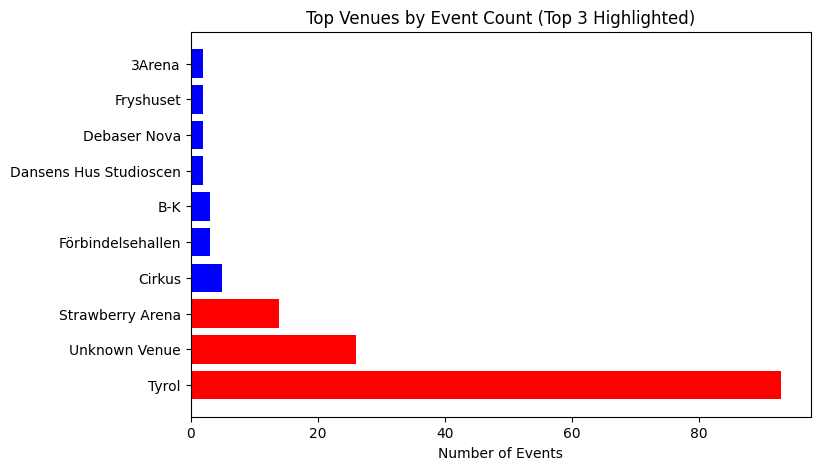

In [48]:
venue_counts = df["venue_name"].value_counts().head(10)

# Get top 3 venues
top3 = venue_counts.head(3).index

# Assign colors
colors = ["red" if venue in top3 else "blue" for venue in venue_counts.index]

fig, ax = plt.subplots(figsize=(8,5))

ax.barh(venue_counts.index, venue_counts.values, color=colors)

ax.set_title("Top Venues by Event Count (Top 3 Highlighted)")
ax.set_xlabel("Number of Events")
swapXY = True

plt.show()

## Events by day of week

In [54]:
events_by_day_of_the_week= con.execute("""
    SELECT day_of_week, COUNT(*) AS total_events
    FROM events
    GROUP BY day_of_week
    ORDER BY total_events DESC;
    """).df()

events_by_day_of_the_week

,day_of_week,total_events
0,Saturday,58
1,Friday,39
2,Thursday,29
3,Monday,11
4,Sunday,11
5,Wednesday,8
6,Tuesday,4


## Events by month of the year 

In [55]:
events_by_month_of_year= con.execute("""
    SELECT month_name, COUNT(*) AS total_events
    FROM events
    GROUP BY month_name
    ORDER BY total_events DESC;
    """).df()

events_by_month_of_year

,month_name,total_events
0,May,33
1,October,24
2,April,22
3,November,22
4,June,17
5,September,16
6,August,14
7,July,10
8,December,2


## Segment - Genre breakdown

In [56]:
segment_genre= con.execute("""
    SELECT segment, genre, COUNT(*) AS total
    FROM events
    GROUP BY segment, genre
    ORDER BY total DESC;
    """).df()

segment_genre

,segment,genre,total
0,Arts & Theatre,Theatre,93
1,Music,Rock,20
2,Music,Other,12
3,Music,Hip-Hop/Rap,8
4,Music,Dance/Electronic,7
5,Arts & Theatre,Dance,4
6,Music,Latin,3
7,Arts & Theatre,Comedy,3
8,Miscellaneous,Family,3
9,Music,Folk,2


## Peak hours oveerall 

In [57]:
overall_peak_hours= con.execute("""
    SELECT hour, COUNT(*) AS total_events
    FROM events
    GROUP BY hour
    ORDER BY hour;
    """).df()

overall_peak_hours

,hour,total_events
0,1.0,1
1,13.0,19
2,14.0,1
3,16.0,1
4,17.0,3
5,18.0,51
6,19.0,60
7,20.0,17
8,21.0,2
9,22.0,1


## Filter events(names) with their segments and genre that occur in Strawberry Arena

In [58]:
events_in_strwb_arena=con.execute("""
   SELECT DISTINCT name, segment, genre
    FROM events
    WHERE venue_name = 'Strawberry Arena'
    """).df()

events_in_strwb_arena

,name,segment,genre
0,Foo Fighters: TAKE COVER TOUR 2026,Music,Rock
1,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Music,Rock
2,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Music,Latin
3,The Weeknd: After Hours Til Dawn Tour | VIP Pa...,Music,Other
4,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour,Music,Latin
5,The Weeknd: After Hours Til Dawn Tour,Music,Other
6,System Of A Down,Music,Rock
7,The Weeknd I Strawberry Arena Premium Experien...,Music,Hip-Hop/Rap
8,The Weeknd : After Hours Til Dawn Tour,Music,Hip-Hop/Rap
9,System Of A Down I VIP Packages,Music,Other
